<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/Linear_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc
)


In [2]:
# Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Dataset shape:", X.shape)
print("Classes:", iris.target_names)


Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
def create_linear_svm():
    return SVC(
        kernel="linear",
        probability=True,   # Needed for ROC
        random_state=42
    )


In [4]:
svm_model = create_linear_svm()


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
conf_matrices = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n================ Fold {fold} ================")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = create_linear_svm()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro")
    rec = recall_score(y_val, y_pred, average="macro")
    cm = confusion_matrix(y_val, y_pred)

    # Store metrics
    fold_metrics.append((acc, prec, rec))
    conf_matrices.append(cm)

    # Print fold-wise metrics
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")



================ Fold 1 ================
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000

================ Fold 2 ================
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000

================ Fold 3 ================
Accuracy  : 0.8667
Precision : 0.8750
Recall    : 0.8667

================ Fold 4 ================
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000

================ Fold 5 ================
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667


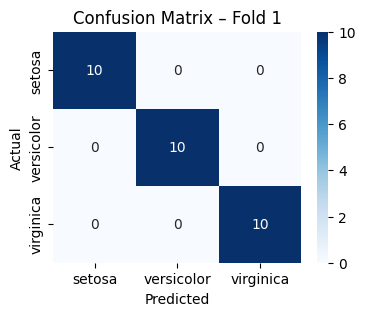

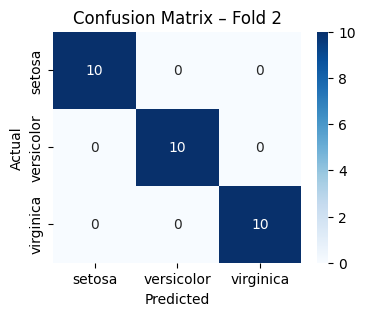

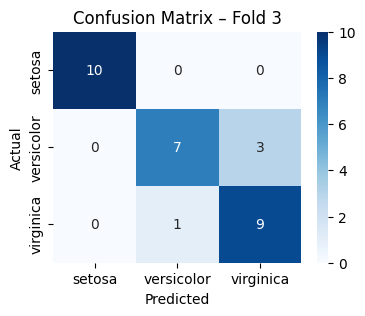

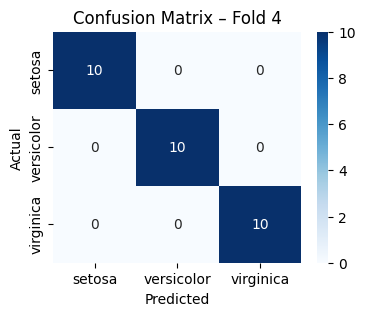

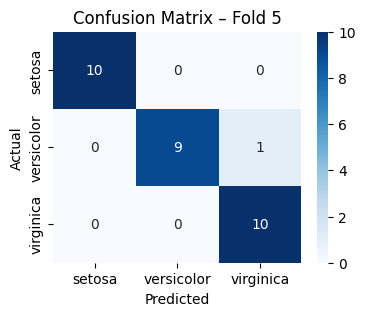

In [12]:
for i, cm in enumerate(conf_matrices, start=1):
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )
    plt.title(f"Confusion Matrix – Fold {i}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


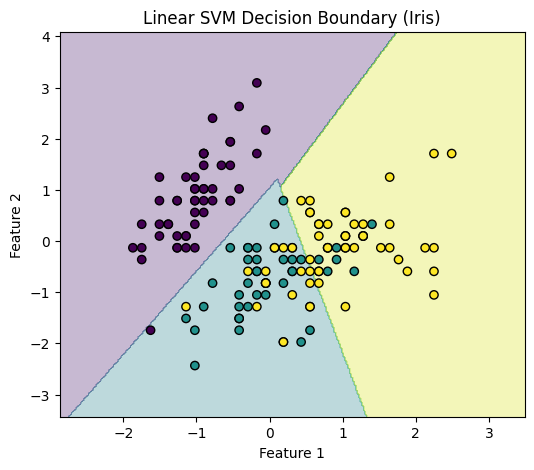

In [8]:
X_vis = X[:, :2]
y_vis = y

model_vis = create_linear_svm()
model_vis.fit(X_vis, y_vis)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolor="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM Decision Boundary (Iris)")
plt.show()


In [13]:
y_bin = label_binarize(y_val, classes=[0, 1, 2])
y_score = model.predict_proba(X_val)


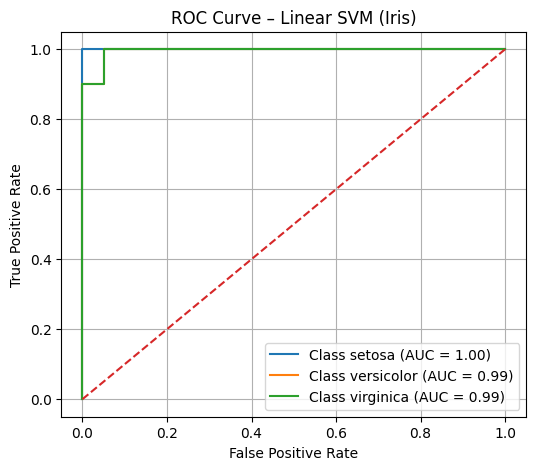

In [14]:
plt.figure(figsize=(6,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {iris.target_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM (Iris)")
plt.legend()
plt.grid()
plt.show()
